In [471]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error 
from sklearn.preprocessing import LabelEncoder
from xgboost import plot_importance
import warnings
warnings.filterwarnings('ignore')

In [472]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
stores=pd.read_csv('stores.csv')
oil=pd.read_csv('oil.csv')
holidays=pd.read_csv('holidays_events.csv')
transactions=pd.read_csv('transactions.csv')
submission=pd.read_csv('sample_submission.csv')

In [473]:
print(train.head())
print(train.shape)
print(train.info())
print(train.isnull().sum())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
(3000888, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [474]:
print(test.head(),'\n')
print(test.shape,"\n")
print(test.info(),'\n')
print(test.isnull().sum(),'\n')

        id        date  store_nbr      family  onpromotion
0  3000888  2017-08-16          1  AUTOMOTIVE            0
1  3000889  2017-08-16          1   BABY CARE            0
2  3000890  2017-08-16          1      BEAUTY            2
3  3000891  2017-08-16          1   BEVERAGES           20
4  3000892  2017-08-16          1       BOOKS            0 

(28512, 5) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB
None 

id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64 



In [475]:
print(stores.head(),'\n')
print(stores.shape,'\n')
print(stores.info(),'\n')
print(stores.isnull().sum(),'\n')

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4 

(54, 5) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None 

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64 



In [476]:
print(oil.head(),'\n')
print(oil.shape,'\n')
print(oil.info(),'\n')
print(oil.isnull().sum(),'\n')

         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20 

(1218, 2) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB
None 

date           0
dcoilwtico    43
dtype: int64 



In [477]:
print(holidays.head(),'\n')
print(holidays.shape,'\n')
print(holidays.info(),'\n')
print(holidays.isnull().sum(),'\n')

         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False   

(350, 6) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  3

In [478]:
print(transactions.head(),'\n')
print(transactions.shape,'\n')
print(transactions.info(),'\n')
print(transactions.isnull().sum(),'\n')

         date  store_nbr  transactions
0  2013-01-01         25           770
1  2013-01-02          1          2111
2  2013-01-02          2          2358
3  2013-01-02          3          3487
4  2013-01-02          4          1922 

(83488, 3) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB
None 

date            0
store_nbr       0
transactions    0
dtype: int64 



In [479]:
print(submission.head(),'\n')
print(submission.shape,'\n')
print(submission.info(),'\n')
print(submission.isnull().sum(),'\n')

        id  sales
0  3000888    0.0
1  3000889    0.0
2  3000890    0.0
3  3000891    0.0
4  3000892    0.0 

(28512, 2) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 445.6 KB
None 

id       0
sales    0
dtype: int64 



In [480]:
def plot_stats(df,columns,ax, color,angle):
    count_classes = df[columns].value_counts()
    ax = sns.barplot(x= count_classes.index , y= count_classes , ax=ax , palette = color)
    ax.set_title(columns.upper(),fontsize=18)
    for tick in ax.get_xticklabels():
        tick.set_rotation(angle)

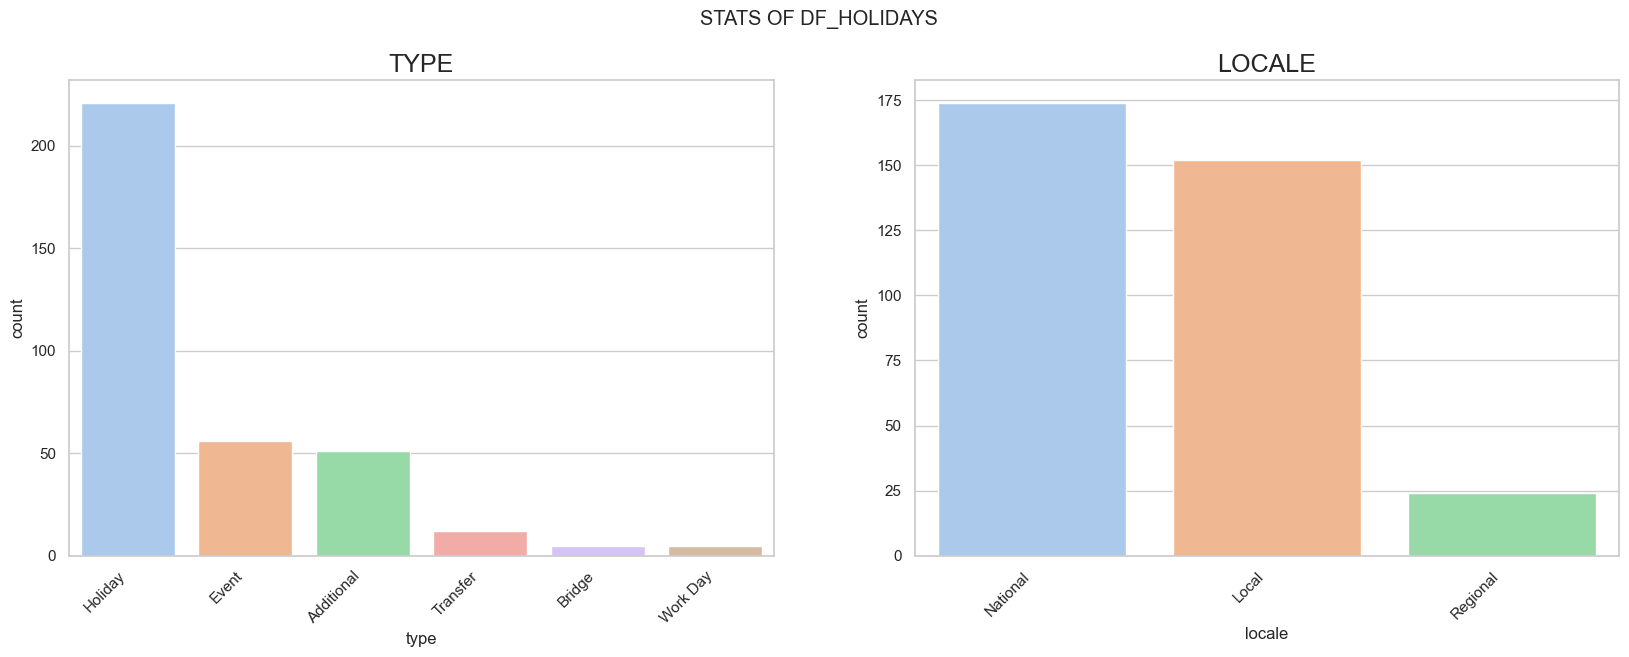

In [481]:
fig , axes = plt.subplots(nrows = 1, ncols = 2,figsize=(20,7))
fig.autofmt_xdate()
fig.suptitle('Stats of df_holidays'.upper())
plot_stats(holidays,'type',axes[0],'pastel',45)
plot_stats(holidays, 'locale',axes[1],'pastel',45)
plt.show()

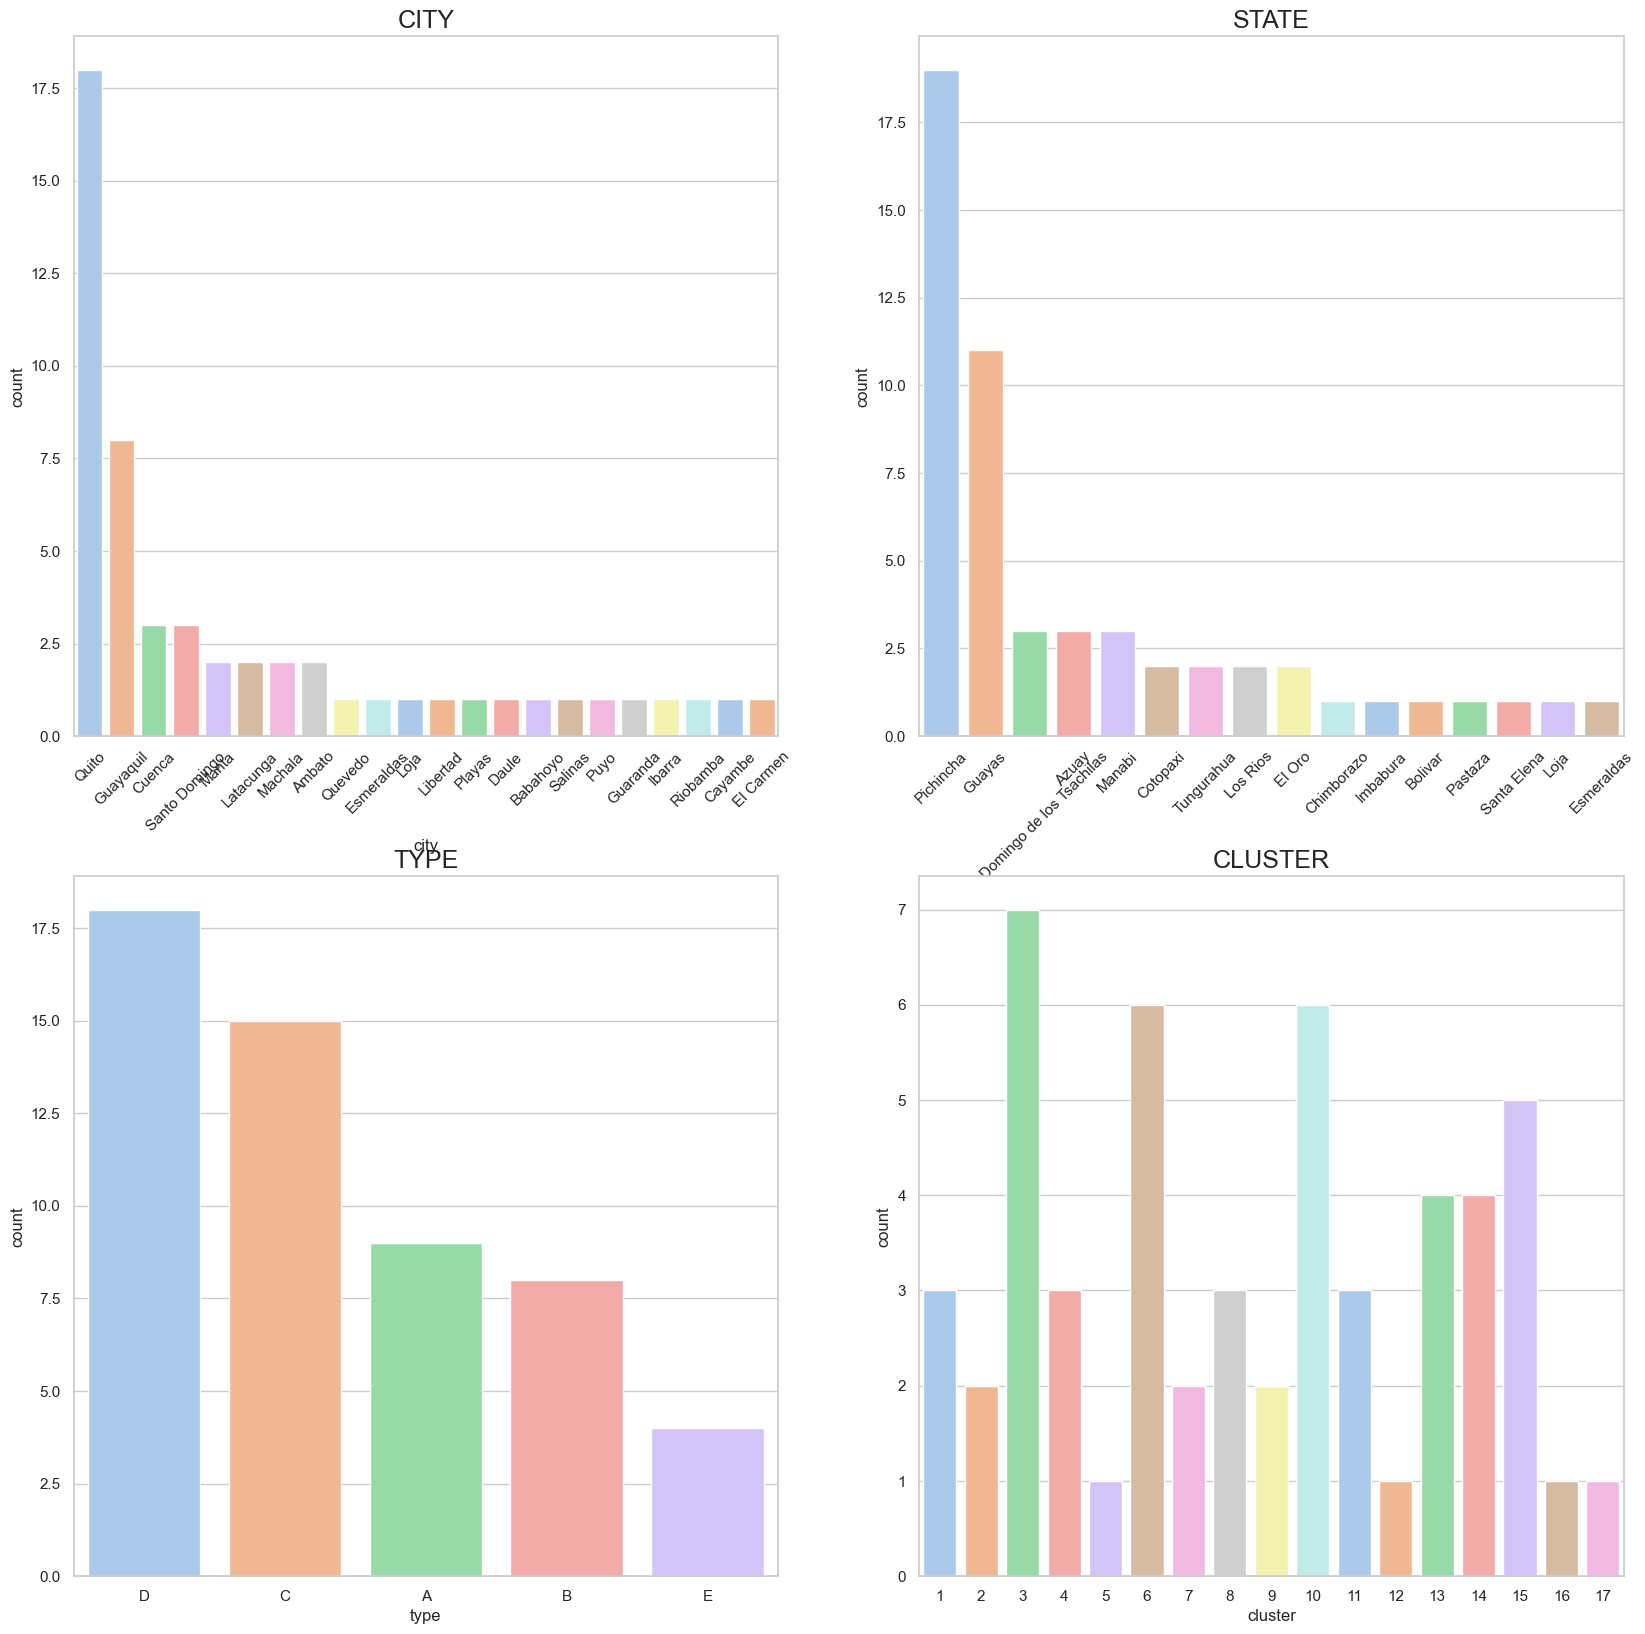

In [482]:
fig , axes = plt.subplots(nrows= 2 , ncols = 2 , figsize= (20,20))
plot_stats(stores, "city", axes[0,0], "pastel", 45)
plot_stats(stores, "state", axes[0,1], "pastel", 45)
plot_stats(stores, "type", axes[1,0], "pastel", 0)
plot_stats(stores, "cluster", axes[1,1], "pastel", 0)
plt.show()

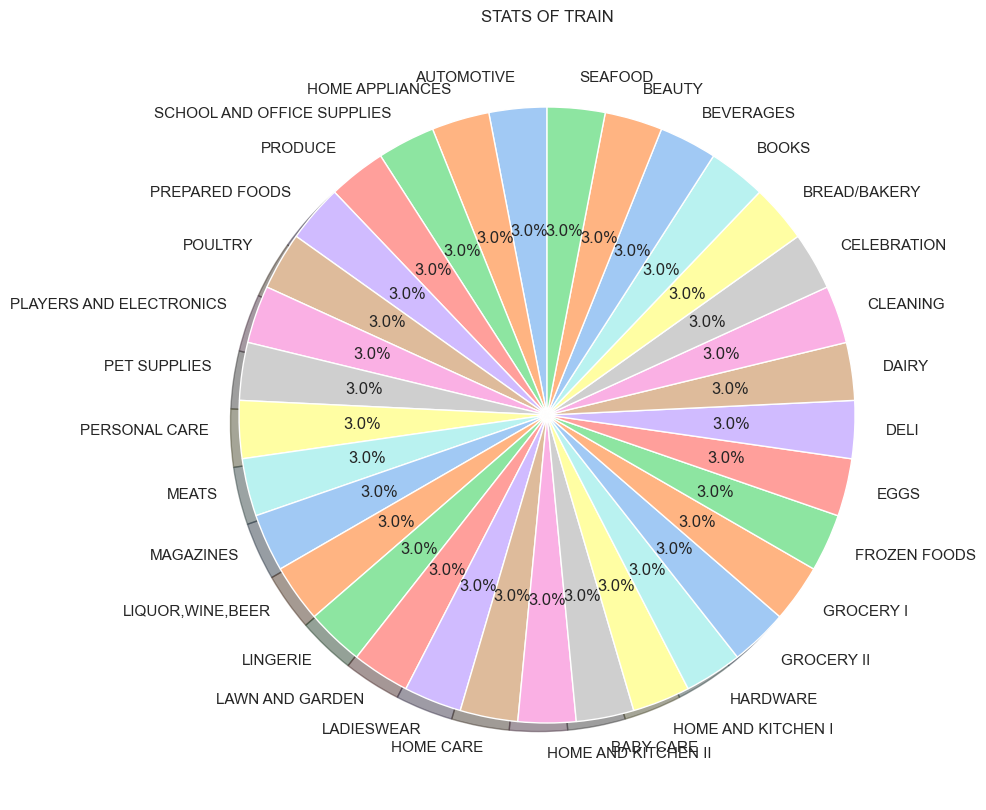

In [483]:
fig, axes = plt.subplots(nrows=1 , ncols = 1, figsize=(10,10))
count_classes = train['family'].value_counts()
pastel= sns.color_palette('pastel')
plt.title('stats of train'.upper())
plt.pie(count_classes, labels = count_classes.index , autopct= '%1.1f%%',shadow= True , startangle= 90 , colors= pastel)
plt.show()

In [484]:
train['date'] = pd.to_datetime(train['date'])
train['year'] =train['date'].dt.year
train['month']= train['date'].dt.month
train['day'] = train['date'].dt.day
train['dow'] = train['date'].dt.dayofweek
train['is_weekend']= (train['dow']>=5).astype(int)

In [485]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dow,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,0


In [487]:
test['date']= pd.to_datetime(test['date'])
test['year']= test['date'].dt.year
test['months']= test['date'].dt.month
test['day']=test['date'].dt.day
test['dow']=test['date'].dt.dayofweek
test['is_weekend']= (train['dow']>=5).astype(int)

In [488]:
test.head()

,id,date,store_nbr,family,onpromotion,year,months,day,dow,is_weekend
0,3000888,2017-08-16,1,AUTOMOTIVE,0,2017,8,16,2,0
1,3000889,2017-08-16,1,BABY CARE,0,2017,8,16,2,0
2,3000890,2017-08-16,1,BEAUTY,2,2017,8,16,2,0
3,3000891,2017-08-16,1,BEVERAGES,20,2017,8,16,2,0
4,3000892,2017-08-16,1,BOOKS,0,2017,8,16,2,0


In [489]:
oil['date'] = pd.to_datetime(oil['date'])
holidays['date']= pd.to_datetime(holidays['date'])
transactions['date']= pd.to_datetime(transactions['date'])

In [490]:
print(oil.head(),'\n')
print(holidays.head(),'\n')
print(transactions.head(),'\n')

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20 

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False   

        date  store_nbr  transactions
0 2013-01-01         25           770
1 2013-01-02          1          2111
2 2013-01-02          2          2358
3 2013-01-02          3          3487
4 2013-01-02          4          1922 



In [491]:
oil= oil.set_index('date').asfreq('D').interpolate().reset_index()

In [492]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


In [493]:
oil.isnull().sum()

date          0
dcoilwtico    1
dtype: int64

In [494]:
oil['dcoilwtico']= oil['dcoilwtico'].fillna(method='bfill')

In [495]:
oil.head()


,date,dcoilwtico
0,2013-01-01,93.140000
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


In [496]:
oil.isnull().sum()

date          0
dcoilwtico    0
dtype: int64

In [497]:
train = train.merge(oil , on = 'date' , how ='left')
test= test.merge(oil,on='date',how='left')

In [498]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dow,is_weekend,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,0,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,0,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,0,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,0,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,0,93.14


In [499]:
test.head()

,id,date,store_nbr,family,onpromotion,year,months,day,dow,is_weekend,dcoilwtico
0,3000888,2017-08-16,1,AUTOMOTIVE,0,2017,8,16,2,0,46.8
1,3000889,2017-08-16,1,BABY CARE,0,2017,8,16,2,0,46.8
2,3000890,2017-08-16,1,BEAUTY,2,2017,8,16,2,0,46.8
3,3000891,2017-08-16,1,BEVERAGES,20,2017,8,16,2,0,46.8
4,3000892,2017-08-16,1,BOOKS,0,2017,8,16,2,0,46.8


In [500]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year',
       'month', 'day', 'dow', 'is_weekend', 'dcoilwtico'],
      dtype='object')

In [501]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year',
       'month', 'day', 'dow', 'is_weekend', 'dcoilwtico'],
      dtype='object')

In [502]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dow,is_weekend,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,0,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,0,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,0,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,0,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,0,93.14


In [503]:
test.head()

,id,date,store_nbr,family,onpromotion,year,months,day,dow,is_weekend,dcoilwtico
0,3000888,2017-08-16,1,AUTOMOTIVE,0,2017,8,16,2,0,46.8
1,3000889,2017-08-16,1,BABY CARE,0,2017,8,16,2,0,46.8
2,3000890,2017-08-16,1,BEAUTY,2,2017,8,16,2,0,46.8
3,3000891,2017-08-16,1,BEVERAGES,20,2017,8,16,2,0,46.8
4,3000892,2017-08-16,1,BOOKS,0,2017,8,16,2,0,46.8


In [504]:
set(test.columns) - set(train.columns)

{'months'}

In [506]:
#set(train.columns) - set(test.columns)
#set(test.columns) - set(train.columns)
test = test.rename(
    columns={'months': 'month'},
    errors='ignore'
)
test.head()

,id,date,store_nbr,family,onpromotion,year,month,day,dow,is_weekend,dcoilwtico
0,3000888,2017-08-16,1,AUTOMOTIVE,0,2017,8,16,2,0,46.8
1,3000889,2017-08-16,1,BABY CARE,0,2017,8,16,2,0,46.8
2,3000890,2017-08-16,1,BEAUTY,2,2017,8,16,2,0,46.8
3,3000891,2017-08-16,1,BEVERAGES,20,2017,8,16,2,0,46.8
4,3000892,2017-08-16,1,BOOKS,0,2017,8,16,2,0,46.8


In [507]:
train= train.sort_values('date')

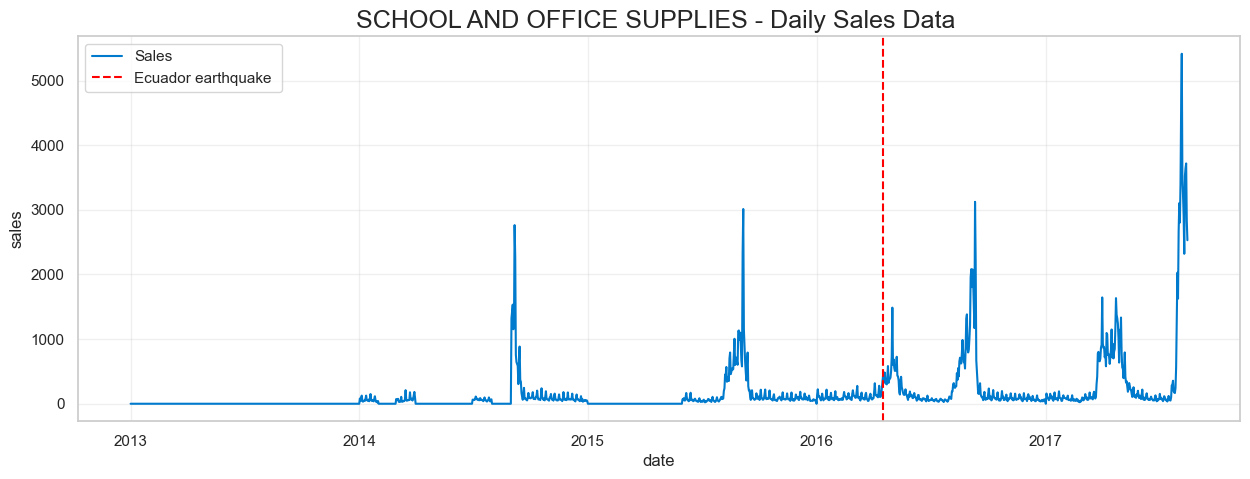

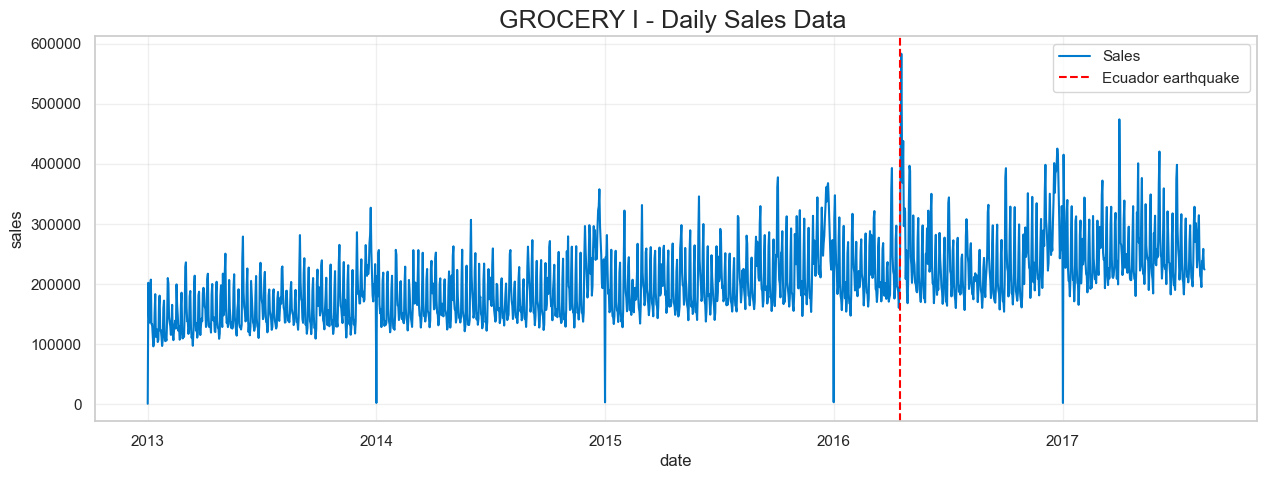

In [508]:
def plot_family_sales(family_name , data):
    family_data = data[data['family']==family_name]
    daily_sales = family_data.groupby('date')['sales'].sum().reset_index()
    
    plt.figure(figsize=(15,5))
    plt.plot(daily_sales['date'], daily_sales['sales'], label='Sales', color='#007acc')
    plt.title(f'{family_name} - Daily Sales Data ', fontsize=18)
    plt.xlabel('date')
    plt.ylabel('sales')
    plt.grid(True, alpha=0.3)
    
    plt.axvline(pd.to_datetime('2016-04-16'),color = 'red', linestyle = '--', label = 'Ecuador earthquake ')
    plt.legend()
    plt.show()
plot_family_sales('SCHOOL AND OFFICE SUPPLIES', train)
plot_family_sales('GROCERY I', train)

In [531]:
def create_advanced_features(df):
    df= df.copy()
    
    df['is_payday']= 0
    df.loc[(df['date'].dt.day==15)|(df['date'].dt.is_month_end),'is_payday']=1

    earthquake_start = pd.to_datetime('2016-04-16')
    earthquake_end = pd.to_datetime('2017-05-15')
    df['is_earhtquake']= 0
    df.loc[(df['date']>=earthquake_start)&(df['date']<=earthquake_end),'is_earthquake']=1

    df['sales_']= df.groupby(['store_nbr','family'])['sales'].transform(lambda x:x.shift(16).rolling(window=30).std() )
    df['promotion_intesity_30']= df.groupby(['store_nbr','family'])['onpromotion'].transform(lambda x:x.shift(16).rolling(window=30).mean())
    df['sales_lag_16'] = df.groupby(['store_nbr','family'])['sales'].shift(16)
    df['sales_lag_30']= df.groupby(['store_nbr','family'])['sales'].shift(30)
    df['rolling_mean_30']= df.groupby(['store_nbr', 'family'])['sales'].transform(lambda x:x.shift(30).rolling(window=30).mean())
    return df
all_date= pd.concat([train,test],sort=False)
all_date= all_date.sort_values(['store_nbr','family','date'])

all_date = create_advanced_features(all_date)

train_new = all_date[all_date['sales'].notnull()]
test_new = all_date[all_date['sales'].isnull()]

train_new = train_new.dropna(subset = ['sales_lag_16'])

outlier_start = pd.to_datetime('2016-04-16')
outlier_end = pd.to_datetime('2015-05-15')

train_new = train_new[(train_new['date']>=outlier_start)|(train_new['date']<outlier_end)]
train_new.head()


,id,date,store_nbr,family,sales,onpromotion,year,month,day,dow,is_weekend,dcoilwtico,is_payday,is_earhtquake,is_earthquake,sales_,promotion_intesity_30,sales_lag_16,sales_lag_30,rolling_mean_30
28512,28512,2013-01-17,1,AUTOMOTIVE,1.0,0,2013,1,17,3,0,95.49,0,0,NaN,NaN,NaN,0.0,NaN,NaN
30294,30294,2013-01-18,1,AUTOMOTIVE,0.0,0,2013,1,18,4,0,95.61,0,0,NaN,NaN,NaN,2.0,NaN,NaN
32076,32076,2013-01-19,1,AUTOMOTIVE,5.0,0,2013,1,19,5,1,95.73,0,0,NaN,NaN,NaN,3.0,NaN,NaN
33858,33858,2013-01-20,1,AUTOMOTIVE,3.0,0,2013,1,20,6,1,95.85,0,0,NaN,NaN,NaN,3.0,NaN,NaN
35640,35640,2013-01-21,1,AUTOMOTIVE,1.0,0,2013,1,21,0,0,95.97,0,0,NaN,NaN,NaN,5.0,NaN,NaN


In [533]:

cols_to_check = ['sales_lag_16', 'sales_lag_30', 'rolling_mean_30', 
                 'sales_', 'promotion_intesity_30']
train_new = train_new.dropna(subset=cols_to_check)
#train_new['sales'] = train_new['sales'].fillna(0)
print("Test NaN:", test_new[cols_to_check].isnull().sum().sum())

Test NaN: 0


In [534]:
y=np.log1p(train_new['sales'])
x=train_new.drop(['id', 'date', 'sales'], axis=1)

In [535]:
le=LabelEncoder()
categorical_cols=['family']
for col in categorical_cols:
    combined_data = pd.concat([x[col], test_new[col]], axis=0)
    le.fit(combined_data)
    x[col] = le.transform(x[col])
    test_new[col] = le.transform(test[col])

In [537]:

x_test=test_new.drop(['id', 'date', 'sales'], axis=1)

In [538]:
#XGBoost
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    early_stopping_rounds=50)

In [539]:
train_size = int(len(x) * 0.9)
x_train, x_val = x.iloc[:train_size], x.iloc[train_size:]
y_train, y_val = y.iloc[:train_size], y.iloc[train_size:]

In [540]:
model.fit(x_train, y_train,eval_set=[(x_train, y_train),(x_val, y_val)],verbose=100)

[0]	validation_0-rmse:2.57189	validation_1-rmse:2.61983
[100]	validation_0-rmse:0.59218	validation_1-rmse:0.58012
[200]	validation_0-rmse:0.54396	validation_1-rmse:0.54536
[300]	validation_0-rmse:0.51898	validation_1-rmse:0.53232
[361]	validation_0-rmse:0.50799	validation_1-rmse:0.53100


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [544]:
predictions_log = model.predict(x_test)
print(model.score(x_train,y_train))
print(model.score(x_val,y_val))

0.9633848065301922
0.9620398299880041


In [545]:
import pickle 
with open('sales_model.pkl','wb') as f:
    pickle.dump(model,f)
print('modle saved')

modle saved
